Importing & Inspecting Pickle File


In [2]:
import pickle

# Load the saved TF-IDF + split data
with open('tfidf_split.pkl', 'rb') as f:
    X_train, X_test, y_train, y_test, tfidf, numeric_cols = pickle.load(f)

# Inspect shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Inspect class distribution again
print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

# Inspect numeric columns included
print("\nNumeric columns used:")
print(numeric_cols)

# Inspect TF-IDF vocabulary size
print("\nNumber of TF-IDF features:", len(tfidf.get_feature_names_out()))

# Show first 10 TF-IDF feature names
print("\nSample TF-IDF features (first 20):")
print(tfidf.get_feature_names_out()[:20])


X_train shape: (27108, 20004)
X_test shape: (4338, 20004)
y_train shape: (27108,)
y_test shape: (4338,)

Training class distribution:
recommended
yes    13554
no     13554
Name: count, dtype: int64

Test class distribution:
recommended
no     3389
yes     949
Name: count, dtype: int64

Numeric columns used:
['neg', 'neu', 'pos', 'compound']

Number of TF-IDF features: 20000

Sample TF-IDF features (first 20):
['aa' 'aa flight' 'ababa' 'abandoned' 'aberdeen' 'ability' 'able'
 'able board' 'able book' 'able change' 'able check' 'able choose'
 'able eat' 'able enjoy' 'able flight' 'able fly' 'able help' 'able make'
 'able provide' 'able seat']


Imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, precision_recall_curve
)
from sklearn.model_selection import learning_curve


Function for evaluate_model

In [4]:
def evaluate_model(model, X_train, y_train, X_test, y_test):

    # Detect label type (string vs numeric)
    unique_labels = set(y_test)

    if unique_labels == {0, 1}:
        pos_label_metric = 1
        labels_cm = [0, 1]
    else:
        pos_label_metric = "yes"
        labels_cm = ["no", "yes"]

    # ---- Predictions ----
    y_pred = model.predict(X_test)

    # ---- Metrics ----
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=pos_label_metric)
    recall = recall_score(y_test, y_pred, pos_label=pos_label_metric)
    f1 = f1_score(y_test, y_pred, pos_label=pos_label_metric)

    print("\n=== MODEL PERFORMANCE ===")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    # ---- Confusion Matrix ----
    cm = confusion_matrix(y_test, y_pred, labels=labels_cm)

    print("\nConfusion Matrix Breakdown:")
    tn, fp, fn, tp = cm.ravel()
    print("TN:", tn)
    print("FP:", fp)
    print("FN:", fn)
    print("TP:", tp)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels_cm, yticklabels=labels_cm)
    plt.title("Confusion Matrix")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

    # ---- ROC & PR Curves (if probability exists) ----
    y_scores = None
    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_test)

    if y_scores is not None:

        # ROC
        fpr, tpr, _ = roc_curve(y_test, y_scores, pos_label=pos_label_metric)
        roc_auc = auc(fpr, tpr)

        plt.figure()
        plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
        plt.plot([0,1], [0,1], 'k--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve")
        plt.legend()
        plt.show()

        # Precision-Recall Curve
        precision_vals, recall_vals, _ = precision_recall_curve(
            y_test, y_scores, pos_label=pos_label_metric
        )
        plt.figure()
        plt.plot(recall_vals, precision_vals)
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Precision-Recall Curve")
        plt.show()

    # ---- Learning Curve ----
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train, cv=5,
        train_sizes=np.linspace(0.1, 1.0, 5),
        scoring="accuracy"
    )

    plt.figure()
    plt.plot(train_sizes, train_scores.mean(axis=1), marker='o', label="Training")
    plt.plot(train_sizes, val_scores.mean(axis=1), marker='o', label="Validation")
    plt.xlabel("Training Samples")
    plt.ylabel("Accuracy")
    plt.title("Learning Curve")
    plt.legend()
    plt.show()


Logistic Regression


=== MODEL PERFORMANCE ===
Accuracy : 0.7688
Precision: 0.4811
Recall   : 0.7250
F1 Score : 0.5784

Confusion Matrix Breakdown:
TN: 2647
FP: 742
FN: 261
TP: 688


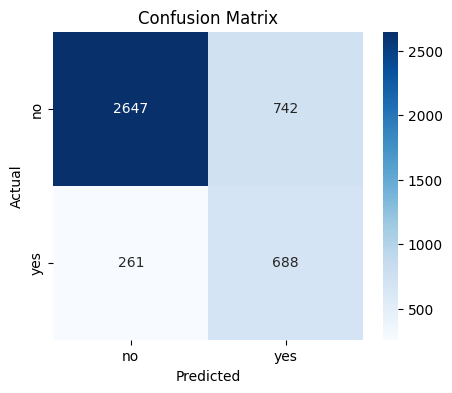

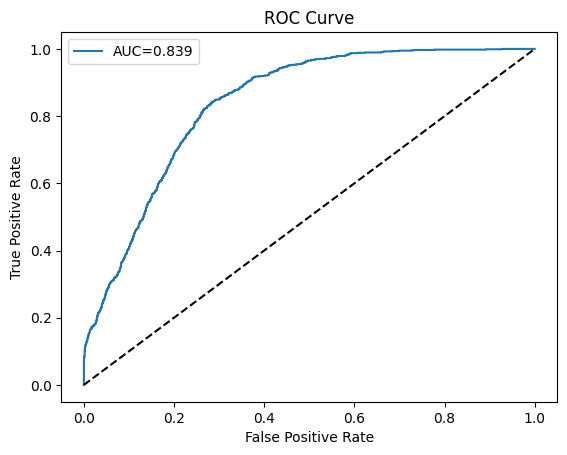

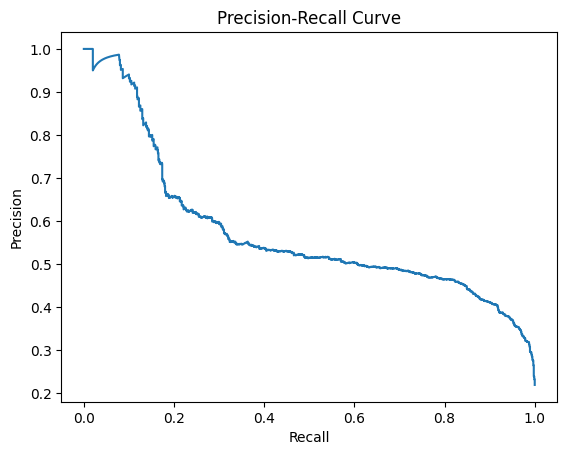

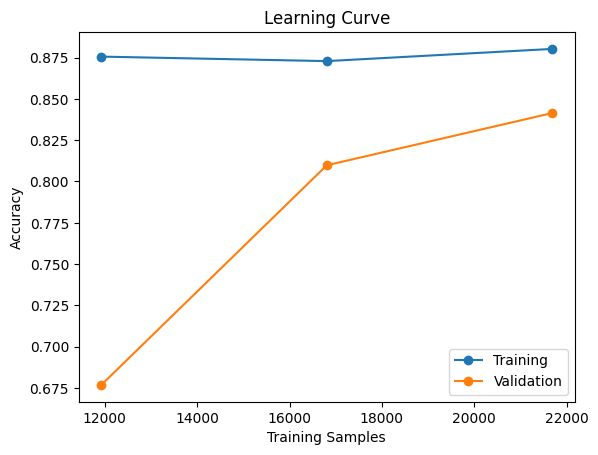

In [5]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    C= 1.0,                
    solver='liblinear',   # Keep this (it's fast and good for text)
    max_iter=3000,
    random_state=42
)

log_reg.fit(X_train, y_train)

evaluate_model(log_reg, X_train, y_train, X_test, y_test)

RF (Random Forest Classifier)


=== MODEL PERFORMANCE ===
Accuracy : 0.7637
Precision: 0.4656
Recall   : 0.5427
F1 Score : 0.5012

Confusion Matrix Breakdown:
TN: 2798
FP: 591
FN: 434
TP: 515


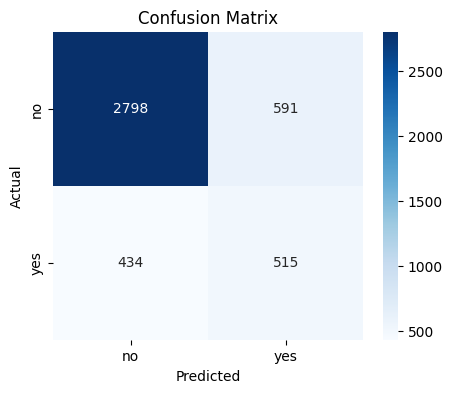

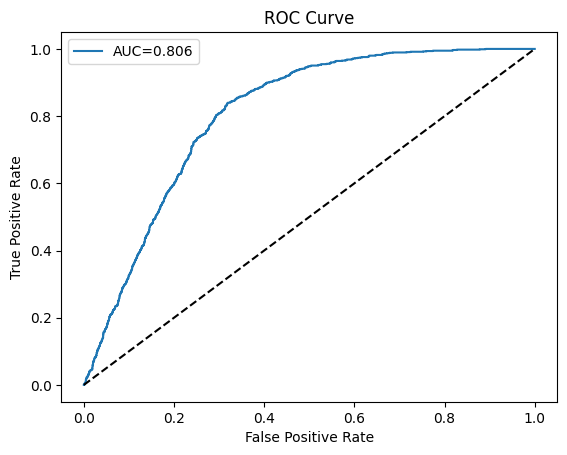

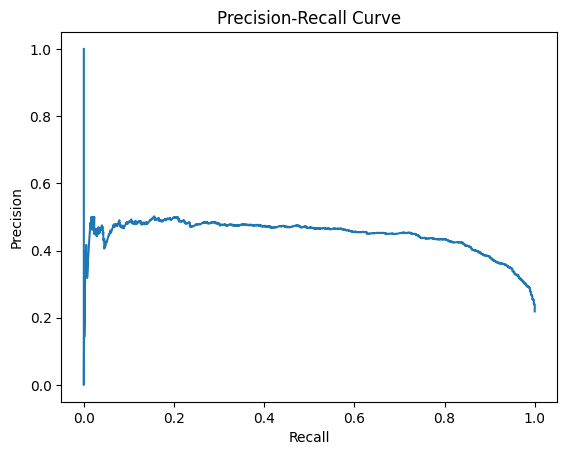

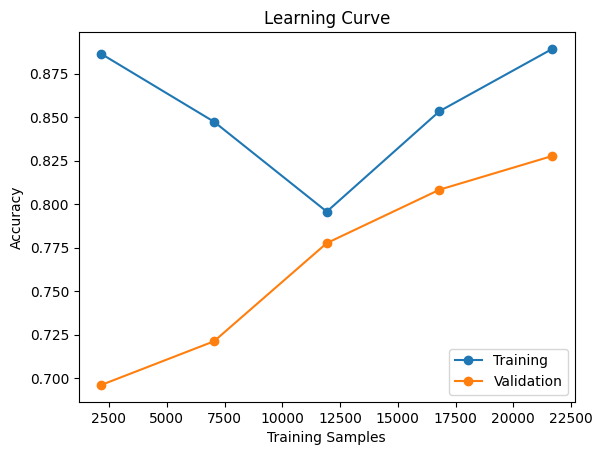

In [6]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,       
    max_depth=20,           
    min_samples_split=10,   
    min_samples_leaf=4,     
    class_weight='balanced',
    n_jobs=-1,              
    random_state=42
)

rf.fit(X_train, y_train)

# NOTE: If the Learning Curve inside evaluate_model is still too slow, 
# you might want to comment it out for now to see the metrics first.
evaluate_model(rf, X_train, y_train, X_test, y_test)

Linear SVC (Support Vector Classification)


=== MODEL PERFORMANCE ===
Accuracy : 0.7683
Precision: 0.4809
Recall   : 0.7429
F1 Score : 0.5839

Confusion Matrix Breakdown:
TN: 2628
FP: 761
FN: 244
TP: 705


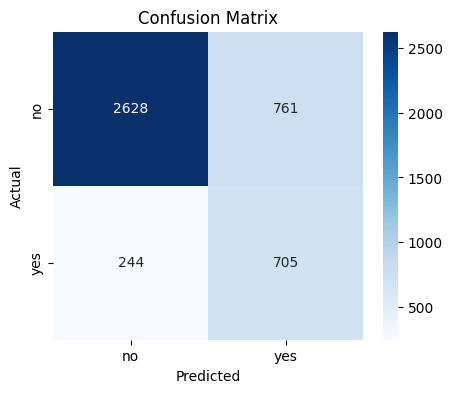

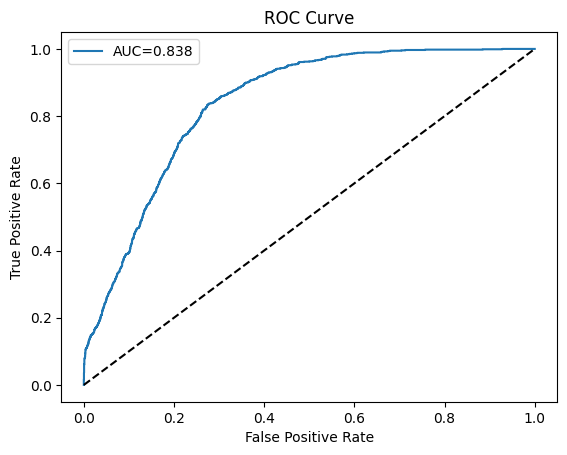

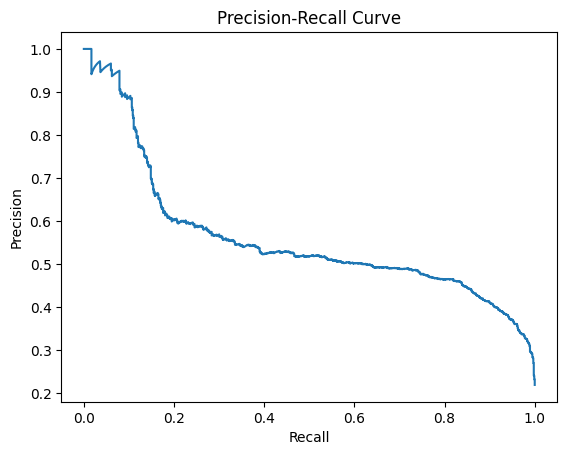

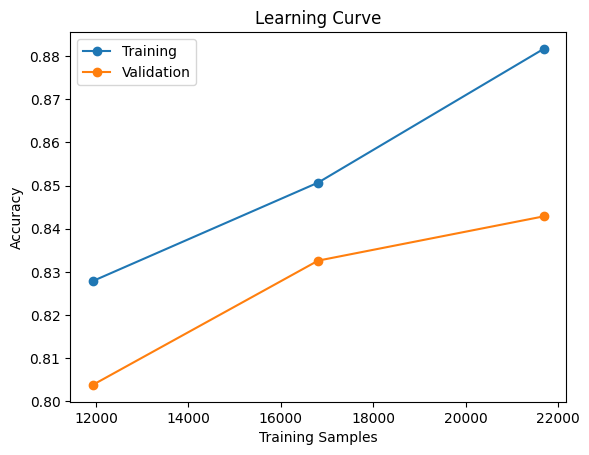

In [7]:
from sklearn.svm import LinearSVC

linear_svc = LinearSVC(
    C=0.1, # improve regularization 
    class_weight='balanced', 
    dual=False,              
    max_iter=10000,          
    random_state=42
)

linear_svc.fit(X_train, y_train)

evaluate_model(linear_svc, X_train, y_train, X_test, y_test)

SGD Classifier


=== MODEL PERFORMANCE ===
Accuracy : 0.7453
Precision: 0.4553
Recall   : 0.8367
F1 Score : 0.5897

Confusion Matrix Breakdown:
TN: 2439
FP: 950
FN: 155
TP: 794


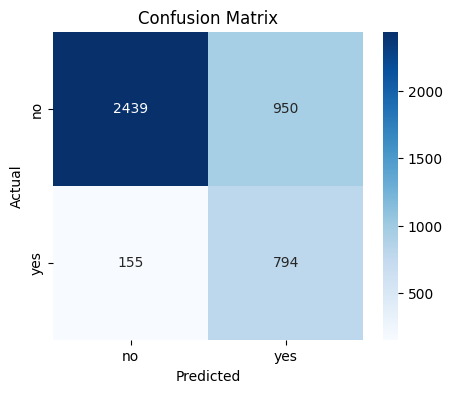

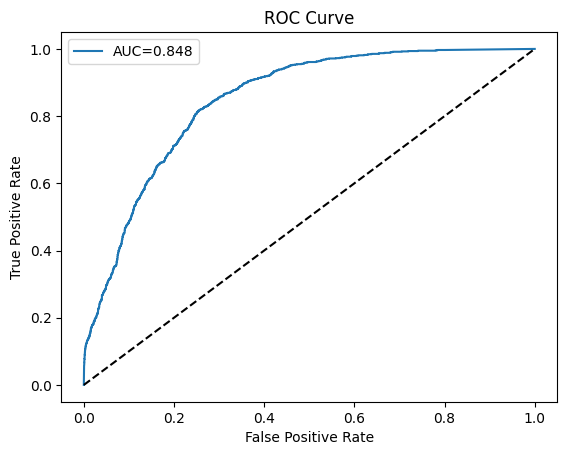

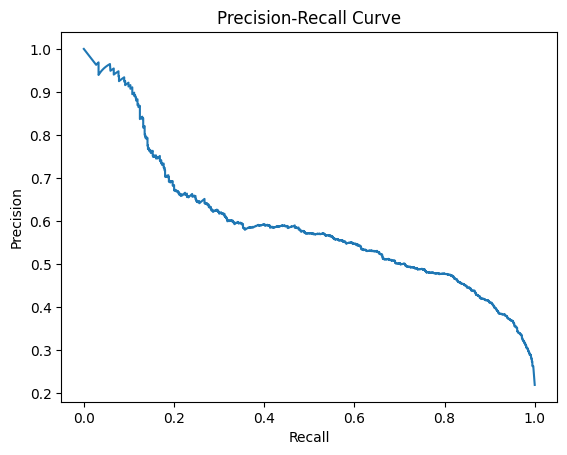

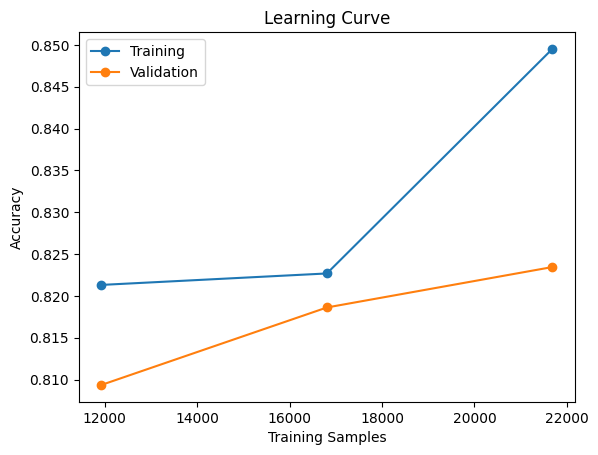

In [8]:
from sklearn.linear_model import SGDClassifier

sgd_model = SGDClassifier(
    loss='modified_huber',   # 'hinge' gives SVM behavior, 'modified_huber' handles probabilities better
    penalty='l2',            # Standard regularization
    alpha=0.001,             # Regularization strength (Tuned to be 'safe' like C=0.1)
    max_iter=1000,
    tol=1e-3,
    class_weight='balanced', # Critical for your imbalanced data
    random_state=42,
    n_jobs=-1                # Uses all CPU cores
)

sgd_model.fit(X_train, y_train)

evaluate_model(sgd_model, X_train, y_train, X_test, y_test)

In [ ]:
import pickle

final_model = log_reg  # <--- Change this if you want to use SGD or LogReg instead

# --- STEP 2: Save the Vectorizer (The Dictionary) ---
with open('tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# --- STEP 3: Save the Model (The Brain) ---
# This saves the mathematical weights needed to make predictions.
with open('sentiment_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

print("Files exported")


Files exported
